In [ ]:
import cv2, os 
import numpy as np
import matplotlib.pyplot as plt 
from typing import List, Dict
from dataclasses import dataclass



import sys, pathlib
HERE = pathlib.Path.cwd()
# If this file is inside a subfolder, try parent too; stop at the first match.
for candidate in (HERE, HERE.parent, HERE.parent.parent):
    if (candidate / "robot").is_dir() and (candidate / "cameras").is_dir() and (candidate / "laser_control").is_dir():
        sys.path.insert(0, str(candidate))
        break
        
from backend.datastorage import SystemDataStore, CaliState
from registration.transformations.depth_estimation import DepthEstimation

Loading Path:  c:\Users\thisi\Documents\MQP\Laser-Stylus-MQP\surgical_system\py_src\image_developement\Calibration Data\calibration_full\20260306\run_001\cali.pkl
NaN ratio: 0.8239749209343616


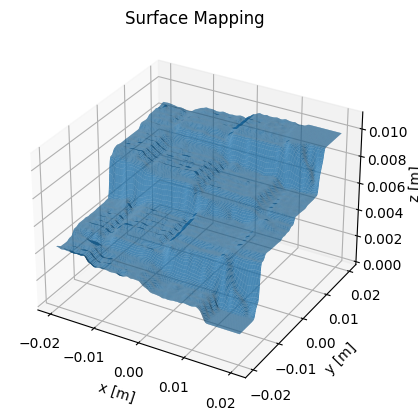

In [2]:
@dataclass(frozen=True)
class homography_stack:
    H_rw: Dict[float, np.ndarray]
    H_tw : Dict[float, np.ndarray]
    H_rt : Dict[float, np.ndarray]
    H_wr: Dict[float, np.ndarray]
    H_wt : Dict[float, np.ndarray]

def read_file():
    directory = os.getcwd() 
    calibration_folder = r"Calibration Data\calibration_full\20260306\run_001\cali.pkl"
    full_path = os.path.join(directory, calibration_folder)
    print("Loading Path: ", full_path)
    
    data_set: List[CaliState] = []
    data_set = SystemDataStore.load_storage(full_path) # list of cali_states
    return data_set

def calculate_stack(data_set):
    
    H_rgb_to_world = {}
    H_therm_to_world = {} 
    H_rgb_to_therm = {}
    
    H_world_to_rgb = {}
    H_world_to_therm = {} 
    
    for cali in data_set:
        height = float(cali.cali_type)
        world_points = cali.payload["obj_Points"]
        rgb_points = cali.payload["rgb_img_points"].T
        therm_points = cali.payload["rgb_img_points"].T
        
        H_rgb_to_world[height] = cv2.findHomography(rgb_points, world_points)[0]
        H_therm_to_world[height] = cv2.findHomography(therm_points, world_points)[0]
        H_rgb_to_therm[height] = cv2.findHomography(rgb_points, therm_points)[0]
        
        H_world_to_rgb[height] = np.linalg.inv(H_rgb_to_world[height])
        H_world_to_therm[height] = np.linalg.inv(H_therm_to_world[height])
        
    dz = 0.0002
    return homography_stack(H_rw = DepthEstimation.create_dense_stack(H_rgb_to_world, dz = dz), 
                            H_tw = DepthEstimation.create_dense_stack(H_therm_to_world, dz = dz), 
                            H_rt = DepthEstimation.create_dense_stack(H_rgb_to_therm, dz = dz),
                            H_wr = DepthEstimation.create_dense_stack(H_world_to_rgb, dz = dz),
                            H_wt = DepthEstimation.create_dense_stack(H_world_to_therm, dz = dz))


def simulate_scan(h_stack: homography_stack, cmd_points, obs_points):
    z_best, err_best, uv_best, conf = DepthEstimation.estimate_depth_from_dense_stack(
            h_stack.H_rw,
            obs_uvs=obs_points,
            cmd_XYs=cmd_points) 
    
    # pair z heights for each pixel 
    
    world_points = np.hstack((cmd_points, z_best[:, None]))
    depth_map, meta = DepthEstimation.generate_depth_mapping(world_points, cell_size = 0.00015)
    depth_map = DepthEstimation.patch_depth(depth_map, smooth_sigma = 0.3, d_f = 10, sigmaColor = 0.2, sigmaSpace = 2)
    DepthEstimation.plot_depth_surface(depth_map, meta)
    return depth_map, meta, z_best, err_best

directory = os.getcwd() 
path = os.path.join(directory, "Calibration Data\scan_points.npz")
scanned_points = np.load(path, allow_pickle=True)
cmd_points, obs_points = scanned_points["cmd_points"], scanned_points["obs_pixels"]
data_set = read_file()
h_stack: homography_stack = calculate_stack(data_set)
depthmap, meta, z, err_best = simulate_scan(h_stack, cmd_points, obs_points)


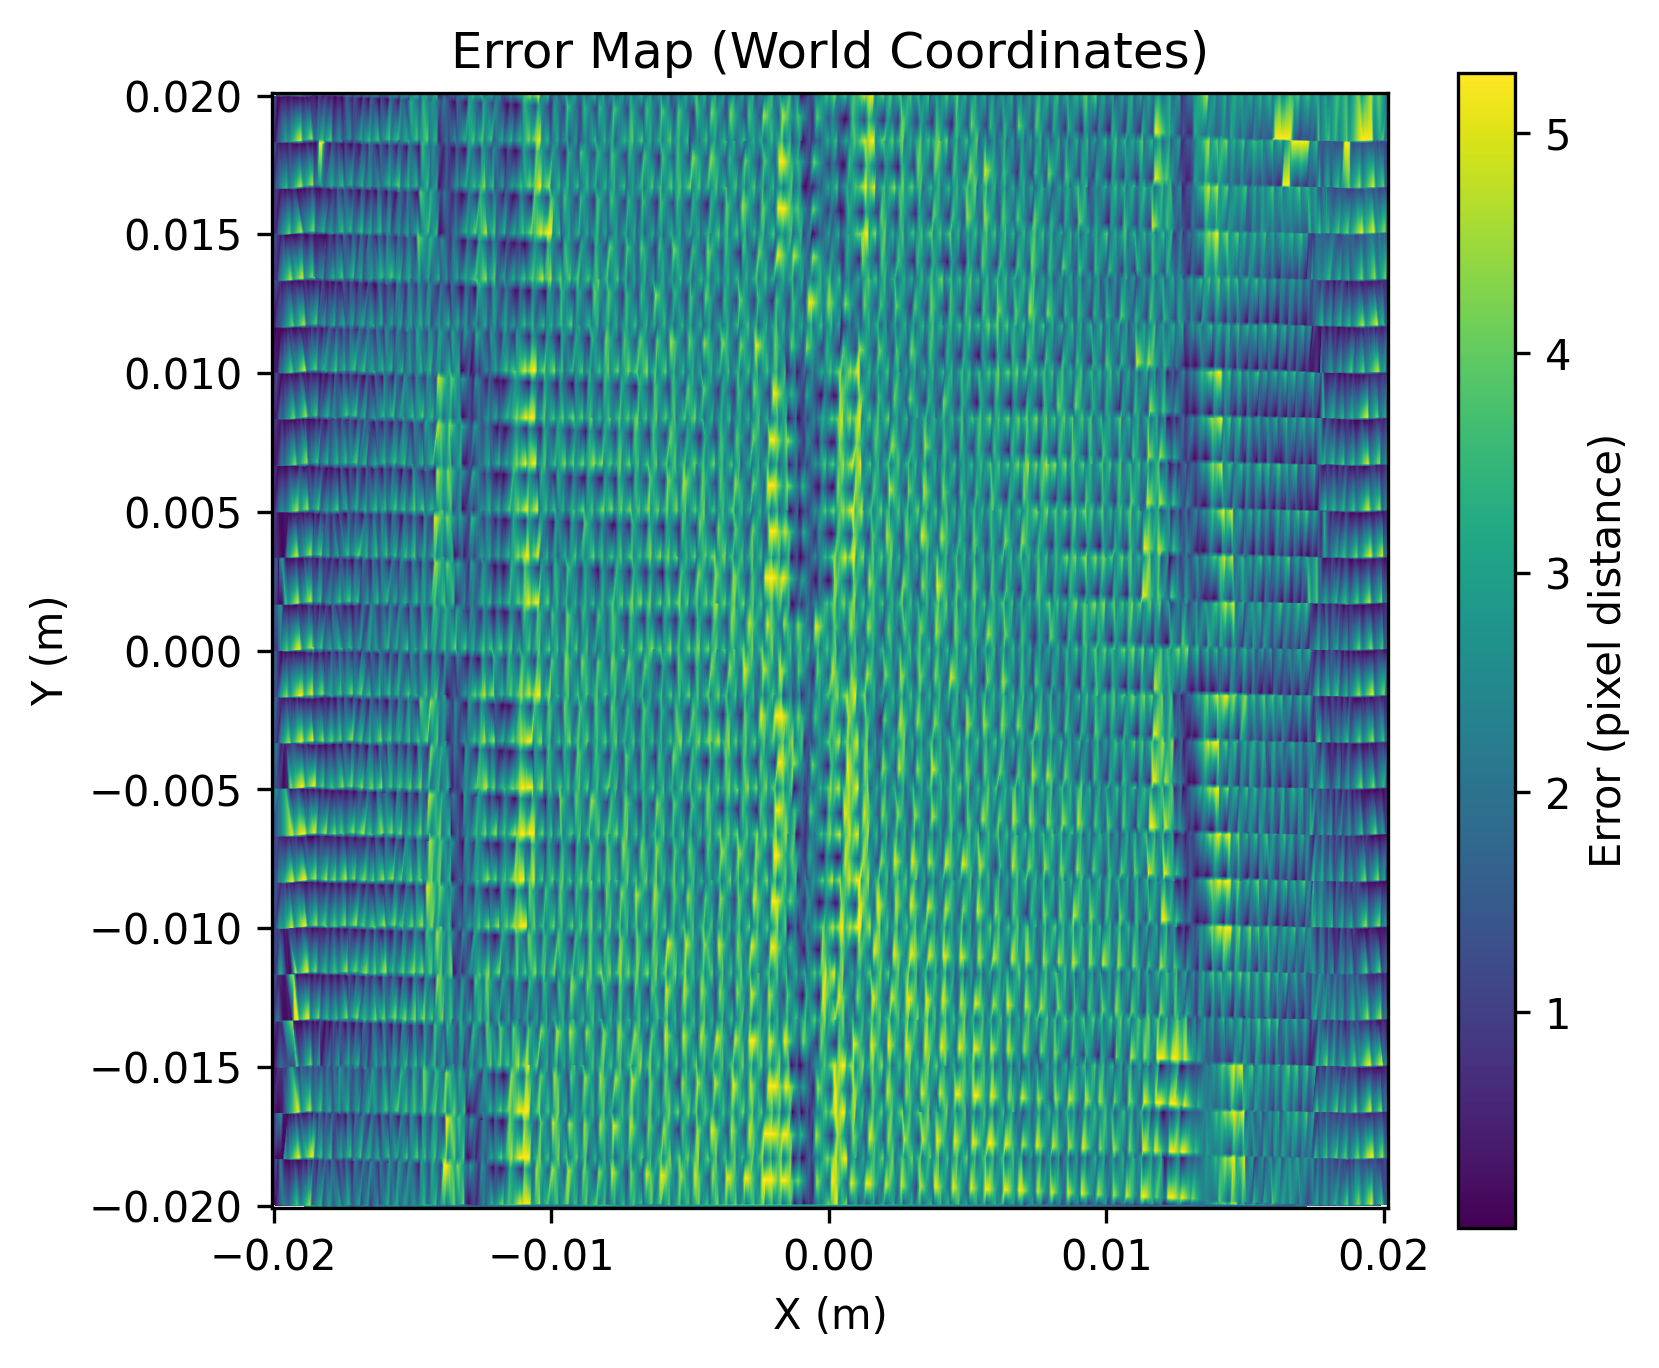

RMSE 5.199613918720374


In [8]:
from scipy.interpolate import griddata

def depth_in_native(resolution, obs_points, z):
    H, W = resolution
    
    u_min = int(np.floor(obs_points[:,0].min()))
    u_max = int(np.ceil(obs_points[:,0].max()))

    v_min = int(np.floor(obs_points[:,1].min()))
    v_max = int(np.ceil(obs_points[:,1].max()))


    grid_u, grid_v = np.meshgrid(
        np.arange(u_min, u_max + 1),
        np.arange(v_min, v_max + 1)
    )
    
    

    Z = griddata(
        obs_points,
        z,
        (grid_u, grid_v),
        method="linear"
    )
    
    plt.figure(figsize=(6,5), dpi=500)
    plt.imshow(Z, cmap="viridis")
    plt.colorbar(label="Height (m)")
    plt.title("Depth / Height Map")
    plt.xlabel("u (pixel)")
    plt.ylabel("v (pixel)")
    plt.show()
    
def disp_error_map(resolution, cmd_points, z):
    
    # resolution now means grid density, not pixels
    Ny, Nx = resolution
    
    X = cmd_points[:,0]
    Y = cmd_points[:,1]

    x_min, x_max = X.min(), X.max()
    y_min, y_max = Y.min(), Y.max()

    # Create world grid
    grid_x, grid_y = np.meshgrid(
        np.linspace(x_min, x_max, Nx),
        np.linspace(y_min, y_max, Ny)
    )


    err = z.copy()
    valid = np.isfinite(err)
    vmin = np.percentile(err[valid], 0)
    vmax = np.percentile(err[valid], 99)
    err = np.clip(err, vmin, vmax)
    
    Z = griddata(
        cmd_points,
        err,
        (grid_x, grid_y),
        method="linear"
    )

    plt.figure(figsize=(6,5), dpi=300)

    plt.imshow(
        Z,
        cmap="viridis",
        origin="lower",
        extent=[x_min, x_max, y_min, y_max]
    )
    

    plt.colorbar(label="Error (pixel distance)")
    plt.xlabel("X (m)")
    plt.ylabel("Y (m)")
    plt.title("Error Map (World Coordinates)")
    plt.show()

resolution = (720, 1280)
# depth_in_native(resolution, obs_points, err_best)
resolution = (1280, 1280)
disp_error_map(resolution, cmd_points, err_best)
print(f"RMSE {np.sqrt(np.mean(err_best**2))}")

u range: 472.91527680052894 770.2757378378224
v range: 140.66668714849175 355.81671427911675
image size: (720, 1280, 3)


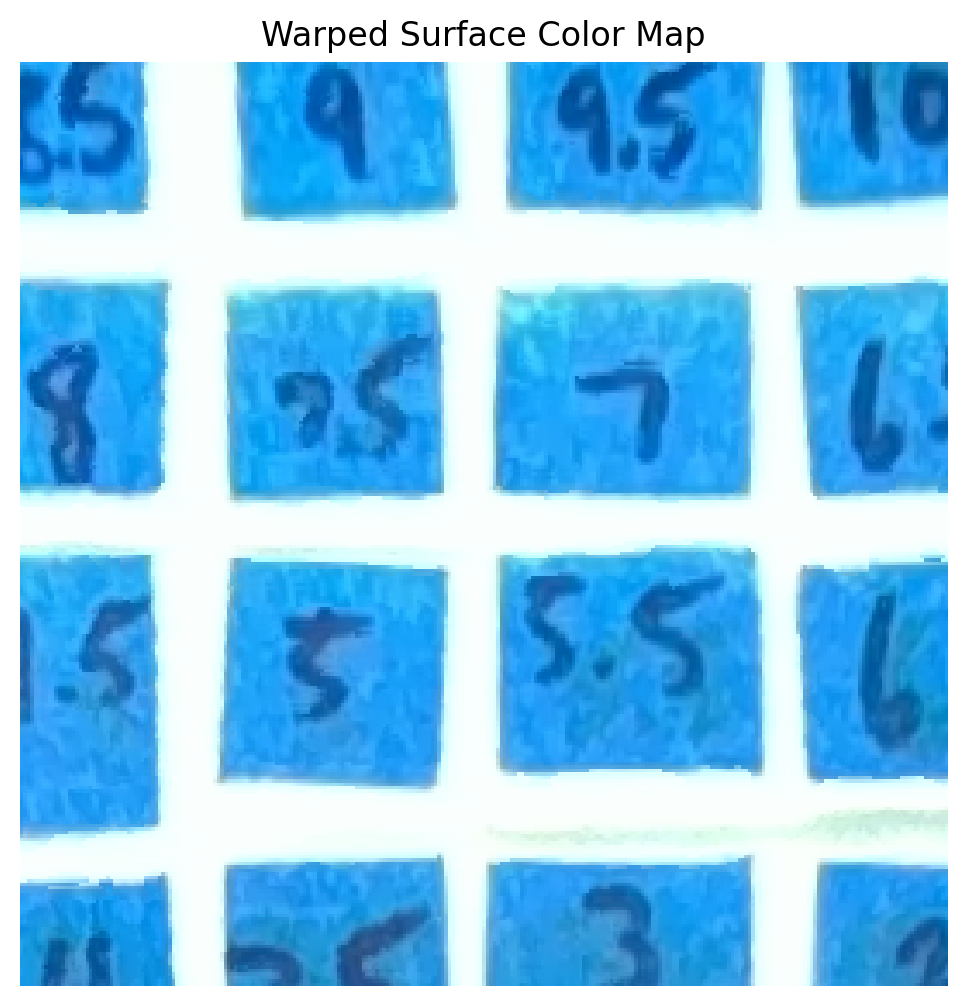

In [4]:
def world_to_camera(depthmap, meta, stack_H):
    """
    Convert every world-grid point in a depth map into its camera pixel.

    Parameters
    ----------
    depthmap : (H,W)
        Height map in meters (or whatever units match stack_H keys).
    meta : dict-like
        Must contain:
            xmin, xmax, ymin, ymax
        describing the world bounds of the depthmap.
    stack_H : homography_stack
        Must contain H_wr, a dict {z: H_world_to_rgb}

    Returns
    -------
    uv_map : (H,W,2)
        Camera pixel coordinates for each world grid cell.
    valid_mask : (H,W)
        True where projection succeeded.
    xyz_world : (H,W,3)
        World coordinates [X,Y,Z] for each cell.
    """
    depthmap = np.asarray(depthmap, dtype=float)
    Hh, Ww = depthmap.shape

    xmin = float(meta["xmin"])
    xmax = float(meta["xmax"])
    ymin = float(meta["ymin"])
    ymax = float(meta["ymax"])

    # ---- build world XY grid matching depthmap cells ----
    xs = np.linspace(xmin, xmax, Ww)
    ys = np.linspace(ymin, ymax, Hh)

    X_grid, Y_grid = np.meshgrid(xs, ys)                                 # (H,W)
    Z_grid = depthmap                                                    # (H,W)

    XY = np.column_stack([X_grid.ravel(), Y_grid.ravel()])               # (N,2)
    Z = Z_grid.ravel()                                                   # (N,)
    N = XY.shape[0]

    # ---- choose nearest available homography for each z ----
    zs_stack = np.array(sorted(stack_H.H_wr.keys()), dtype=float)        # (K,)
    idx_z = np.abs(Z[:, None] - zs_stack[None, :]).argmin(axis=1)        # (N,)

    uv = np.full((N, 2), np.nan, dtype=float)

    # ---- project by z-bin ----
    for k, z_key in enumerate(zs_stack):
        sel = (idx_z == k) & np.isfinite(Z)
        if not np.any(sel):
            continue

        H = np.asarray(stack_H.H_wr[float(z_key)], dtype=float)          # world -> rgb
        uv[sel] = DepthEstimation.project_xy(H, XY[sel])

    uv_map = uv.reshape(Hh, Ww, 2)
    valid_mask = np.isfinite(uv_map[..., 0]) & np.isfinite(uv_map[..., 1])

    xyz_world = np.stack([X_grid, Y_grid, Z_grid], axis=-1)
    return uv_map, valid_mask, xyz_world

def bilinear_sample_image(img, uv_map):
    """
    img:    (H_img, W_img) or (H_img, W_img, C)
    uv_map: (H_out, W_out, 2), where uv_map[...,0]=u and uv_map[...,1]=v

    returns:
        out: sampled image of shape (H_out, W_out) or (H_out, W_out, C)
    """
    u = uv_map[..., 0]
    v = uv_map[..., 1]

    h_img, w_img = img.shape[:2]
    h_out, w_out = u.shape

    # floor / ceil neighbors
    u0 = np.floor(u).astype(int)
    v0 = np.floor(v).astype(int)
    u1 = u0 + 1
    v1 = v0 + 1

    # validity mask
    valid = (u0 >= 0) & (v0 >= 0) & (u1 < w_img) & (v1 < h_img)

    # interpolation weights
    du = u - u0
    dv = v - v0

    wa = (1 - du) * (1 - dv)
    wb = (1 - du) * dv
    wc = du * (1 - dv)
    wd = du * dv

    # output allocation
    if img.ndim == 3:
        c = img.shape[2]
        out = np.zeros((h_out, w_out, c), dtype=np.float32)

        Ia = img[v0[valid], u0[valid]].astype(np.float32)  # (N, C)
        Ib = img[v1[valid], u0[valid]].astype(np.float32)
        Ic = img[v0[valid], u1[valid]].astype(np.float32)
        Id = img[v1[valid], u1[valid]].astype(np.float32)

        out_valid = (
            Ia * wa[valid, None] +
            Ib * wb[valid, None] +
            Ic * wc[valid, None] +
            Id * wd[valid, None]
        )  # (N, C)

        out[valid, :] = out_valid

    else:
        out = np.zeros((h_out, w_out), dtype=np.float32)

        Ia = img[v0[valid], u0[valid]].astype(np.float32)
        Ib = img[v1[valid], u0[valid]].astype(np.float32)
        Ic = img[v0[valid], u1[valid]].astype(np.float32)
        Id = img[v1[valid], u1[valid]].astype(np.float32)

        out_valid = (
            Ia * wa[valid] +
            Ib * wb[valid] +
            Ic * wc[valid] +
            Id * wd[valid]
        )

        out[valid] = out_valid

    return out, valid

img = cv2.imread("Calibration Data\step_img.png")

if img.ndim == 3 and img.shape[2] >= 3:
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

uv_map, valid_mask, xyz_world = world_to_camera(depthmap, meta, h_stack)

print("u range:", uv_map[... ,0].min(), uv_map[...,0].max())
print("v range:", uv_map[...,1].min(), uv_map[...,1].max())
print("image size:", img.shape)

out, valid = bilinear_sample_image(img, uv_map)
img_out = np.flipud(out)
plt.figure(figsize=(6,6), dpi=200)
plt.imshow(img_out.astype(np.uint8))
plt.title("Warped Surface Color Map")
plt.axis("off")
plt.show()

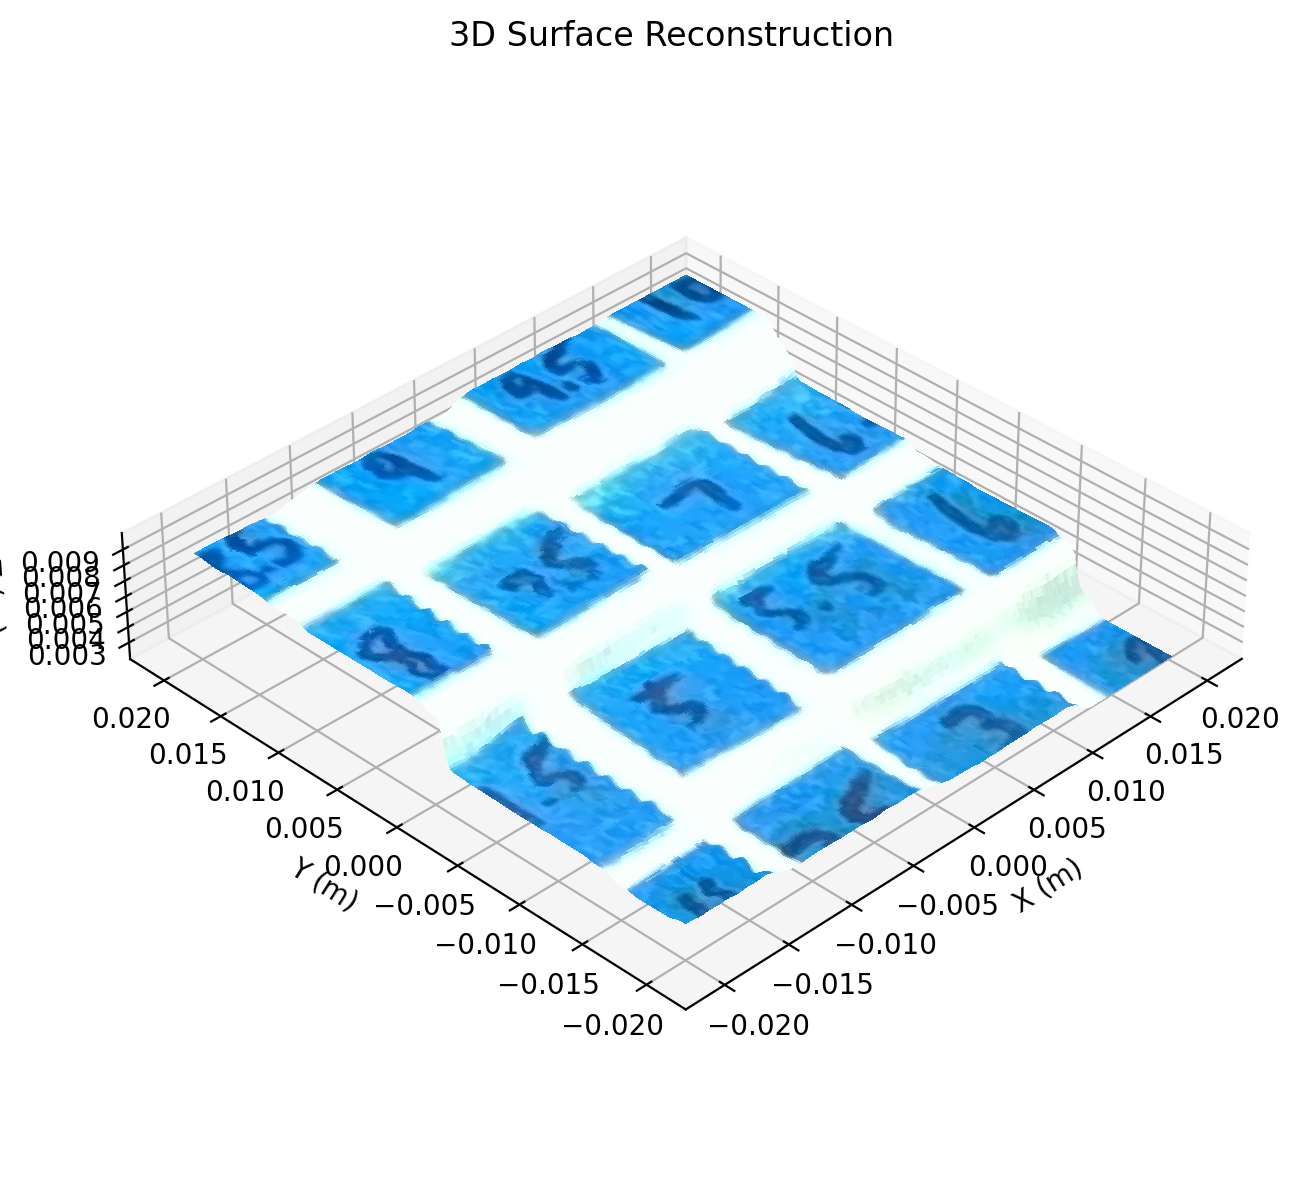

In [5]:
def plot_surface_3d(depthmap, meta, color_map=None, stride=1, z_scale=1.0):
    Z = np.asarray(depthmap, dtype=float) * z_scale
    H, W = Z.shape

    xs = np.linspace(meta["xmin"], meta["xmax"], W)
    ys = np.linspace(meta["ymin"], meta["ymax"], H)
    X, Y = np.meshgrid(xs, ys)

    # Downsample consistently
    X = X[::stride, ::stride]
    Y = Y[::stride, ::stride]
    Z = Z[::stride, ::stride]

    fig = plt.figure(figsize=(8, 6), dpi=200)
    ax = fig.add_subplot(111, projection="3d")

    if color_map is not None:
        C = np.asarray(color_map)[::stride, ::stride]

        # Normalize colors to [0,1]
        if C.dtype == np.uint8:
            C = C.astype(np.float32) / 255.0
        else:
            C = np.clip(C.astype(np.float32), 0.0, 1.0)

        # Convert vertex colors -> face colors
        # One color per quad
        facecolors = C[:-1, :-1, :]

        # Face-valid mask: require all 4 corners finite
        valid_faces = (
            np.isfinite(Z[:-1, :-1]) &
            np.isfinite(Z[1:, :-1]) &
            np.isfinite(Z[:-1, 1:]) &
            np.isfinite(Z[1:, 1:])
        )

        # Add alpha channel if missing
        if facecolors.shape[-1] == 3:
            alpha = valid_faces.astype(np.float32)[..., None]
            facecolors = np.concatenate([facecolors, alpha], axis=-1)
        else:
            facecolors[..., 3] *= valid_faces.astype(np.float32)

        # Replace invalid Z with nan
        Z_plot = Z.copy()
        Z_plot[~np.isfinite(Z_plot)] = np.nan

        ax.plot_surface(
            X, Y, Z_plot,
            facecolors=facecolors,
            rstride=1, cstride=1,
            linewidth=0,
            edgecolor="none",
            antialiased=False,
            shade=False
        )

    else:
        Z_plot = Z.copy()
        Z_plot[~np.isfinite(Z_plot)] = np.nan

        ax.plot_surface(
            X, Y, Z_plot,
            cmap="viridis",
            linewidth=0,
            edgecolor="none",
            antialiased=False,
            shade=False
        )

    ax.set_xlabel("X (m)")
    ax.set_ylabel("Y (m)")
    ax.set_zlabel("Z (m)")
    ax.set_title("3D Surface Reconstruction")
    ax.view_init(elev=35, azim=-135)

    # Better aspect ratio
    xspan = meta["xmax"] - meta["xmin"]
    yspan = meta["ymax"] - meta["ymin"]
    zspan = np.nanmax(Z) - np.nanmin(Z)
    zspan = max(zspan, 1e-6)
    ax.set_box_aspect((xspan, yspan, zspan))

    plt.tight_layout()
    plt.show()
    
C = np.asarray(out)

if np.issubdtype(C.dtype, np.integer):
    C = C.astype(np.float32) / 255.0
else:
    C = C.astype(np.float32)
    if C.max() > 1.0:
        C = C / 255.0
    C = np.clip(C, 0.0, 1.0)
    

plot_surface_3d(depthmap, meta, C)